# Домашнее задание к семинару 13 (HW13)
Тема: токенизация текста, инференс готовой BERT-подобной модели и базовый fine-tuning для классификации текста.

## Импорты, seed и среда

In [ ]:
# Базовые библиотеки для воспроизводимости, анализа и визуализации.
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import datasets
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

In [ ]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [ ]:
MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"

## Данные и первичный анализ

In [ ]:
df = datasets.load_dataset("emotion")

train_df = pd.DataFrame({
    "text": df["train"]["text"],
    "label": df["train"]["label"]})

val_df = pd.DataFrame({
    "text": df["validation"]["text"],
    "label": df["validation"]["label"]})

test_df = pd.DataFrame({
    "text": df["test"]["text"],
    "label": df["test"]["label"]})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
# Смотрим размер датасета и распределение по классам.
print("Размер train выборки:", len(train_df))
print("Размер val выборки:", len(val_df))
print("Размер test выборки:", len(test_df))

display(train_df["label"].value_counts())

display(train_df.sample(6, random_state=42).reset_index(drop=True))

Размер train выборки: 16000
Размер val выборки: 2000
Размер test выборки: 2000


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


,text,label
0,ive made it through a week i just feel beaten down,0
1,i feel this strategy is worthwhile,1
2,i feel so worthless and weak what does he have to say that s what i want to find out,0
3,i feel clever nov,1
4,im moved in ive been feeling kind of gloomy,0
5,i allowed myself to feel the really shitty feelings while i was running because a the endorphins were flowing so it hurt less and b so i...,0


In [ ]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nРаспределение классов в train:")
display(train_df["label"].value_counts())

print("Распределение классов в validation:")
display(val_df["label"].value_counts())

print("Распределение классов в test:")
display(test_df["label"].value_counts())

Train: (16000, 2)
Validation: (2000, 2)
Test: (2000, 2)

Распределение классов в train:


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


Распределение классов в validation:


,count
label,
1,704
0,550
3,275
4,212
2,178
5,81


Распределение классов в test:


,count
label,
1,695
0,581
3,275
4,224
2,159
5,66


In [ ]:
train_df.head(10)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2
4,i am feeling grouchy,3
5,ive been feeling a little burdened lately wasnt sure why that was,0
6,ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny,5
7,i feel as confused about life as a teenager or as jaded as a year old man,4
8,i have been with petronas for years i feel that petronas has performed well and made a huge profit,1
9,i feel romantic too,2


Классифицируются сообщения в Twitter выражающие шесть базовых эмоций: гнев, страх, радость, любовь, грусть, удивление. Колонки: text, label.

## Токенизация

In [ ]:
# sadness (0), joy (1), love (2), anger (3), fear (4), surprise (5)
label_names = df["train"].features["label"].names

id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

for df in (train_df, val_df, test_df):
    df["label_name"] = df["label"].map(id2label)

    print("label2id:", label2id)
    print("id2label:", id2label)

label2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
label2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
label2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [ ]:
# Приводим датафреймы к формату HuggingFace Dataset.
train_ds = Dataset.from_pandas(
    train_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
val_ds = Dataset.from_pandas(
    val_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
test_ds = Dataset.from_pandas(
    test_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True),
    preserve_index=False,
)

dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 2000
    })
})

In [ ]:
# Посмотрим на несколько примеров.
print("Пример из train:")
display(dataset_dict["train"][:3])

print("Пример из validation:")
display(dataset_dict["validation"][:3])

Пример из train:


{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong'],
 'labels': [0, 0, 3]}

Пример из validation:


{'text': ['im feeling quite sad and sorry for myself but ill snap out of it soon',
  'i feel like i am still looking at a blank canvas blank pieces of paper',
  'i feel like a faithful servant'],
 'labels': [0, 0, 2]}

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)

# Удаляем столбец "text": DataCollatorWithPadding попытается преобразовать
# все поля датасета в тензоры, а строки в тензор не конвертируются.
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded: BertTokenizer
Model checkpoint: nlptown/bert-base-multilingual-uncased-sentiment


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [ ]:
# Data collator будет добавлять padding динамически, прямо при формировании батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

labels: shape=(3,)
input_ids: shape=(3, 28)
token_type_ids: shape=(3, 28)
attention_mask: shape=(3, 28)


In [ ]:
# Базовый разбор токенизации
tokenizer_example = AutoTokenizer.from_pretrained(MODEL_NAME)

def inspect_texts(texts: list, tokenizer) -> list:
    """Анализирует каждый текст отдельно и возвращает список DataFrame"""
    results = []

    for i, text in enumerate(texts):
        tokens = tokenizer.tokenize(text)
        token_ids = tokenizer.encode(text, add_special_tokens=True)

        df = pd.DataFrame({
            "position": list(range(len(tokens))),
            "token": tokens,
            "token_id": token_ids,
        })
        results.append(df)

        print(f"\n--- Текст {i+1} ---")
        print(f"Оригинал: {text}")
        print(f"Длина в токенах: {len(tokens)}")
        print(f"Специальные токены: [CLS] в начале, [SEP] в конце")
        print(df.to_string(index=False))
        print()

    return results

example_texts = train_ds[:3]["text"]

print("Исходные тексты:")
for i, text in enumerate(example_texts, 1):
    print(f"{i}. {text}")
print()

tokenized = tokenizer_example(
    example_texts,
    add_special_tokens=True,
    padding=True,
    return_tensors='pt'
)

print("\n1. Input IDs (с паддингом и спецтокенами):")
print(tokenized['input_ids'])
print(f"\nФорма: {tokenized['input_ids'].shape}")

print("\n2. Attention Mask:")
print(tokenized['attention_mask'])

print("\n3. Специальные токены:")
print(f"  [CLS] - {tokenizer_example.cls_token} (id: {tokenizer_example.cls_token_id}) - начало последовательности")
print(f"  [SEP] - {tokenizer_example.sep_token} (id: {tokenizer_example.sep_token_id}) - разделитель/конец")
print(f"  [PAD] - {tokenizer_example.pad_token} (id: {tokenizer_example.pad_token_id}) - паддинг")

print("\n4. Детальный разбор каждого текста:")
print("-" * 70)

# Анализируем каждый текст отдельно
for i, text in enumerate(example_texts):
    tokens = tokenizer_example.tokenize(text)
    token_ids = tokenizer_example.encode(text, add_special_tokens=True)

    print(f"\nТекст {i+1}: \"{text[:50]}{'...' if len(text) > 50 else ''}\"")
    print(f"   Длина: {len(tokens)} токенов")

    # Показываем токены с аннотацией спецтокенов
    print(f"\n   Токены и их ID:")
    for pos, (tok, tid) in enumerate(zip(tokens, token_ids)):
        if tid == tokenizer_example.cls_token_id:
            marker = " [CLS]"
        elif tid == tokenizer_example.sep_token_id:
            marker = " [SEP]"
        elif tid == tokenizer_example.pad_token_id:
            marker = " [PAD]"
        else:
            marker = ""
        print(f"      {pos:3d}: {tok:15s} -> {tid:5d}{marker}")

print("\n" + "=" * 70)
print("5. Декодирование западдингованных ID:")
decoded_batch = tokenizer_example.decode(tokenized['input_ids'][0])
print(f"Текст 1 (декодирован): {decoded_batch}")

# Показываем разницу между текстами разной длины
print("\n6. Демонстрация паддинга:")
lengths = [len(tokenizer_example.encode(t, add_special_tokens=True)) for t in example_texts]
max_len = max(lengths)
print(f"   Длины текстов в токенах: {lengths}")
print(f"   Максимальная длина: {max_len}")
print(f"   Короткие тексты дополнены до {max_len} токенами с помощью [PAD]")

print('\n' + '-' * 70)

Исходные тексты:
1. i didnt feel humiliated
2. i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
3. im grabbing a minute to post i feel greedy wrong


1. Input IDs (с паддингом и спецтокенами):
tensor([[  101,   151, 30557, 10123, 23333, 52179, 50524, 11894,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0],
        [  101,   151, 10743, 11335, 10195, 35260, 10297, 18763, 15470, 10114,
         10297, 12235, 19803, 18763, 15836, 12125, 10195, 11352, 12096, 25839,
         10488, 11258, 10107, 10110, 10127, 37079, 21518,   102],
        [  101, 10205, 50470, 27058,   143, 18471, 10114, 10404,   151, 23333,
         50565, 46742, 33413,   102,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0]])

Форма: torch.Size([3, 28])

2. Attention Mask:
tensor([[1, 1, 1, 1, 1, 1,

## Инференс готовой модели

In [ ]:
# Загружаем модель для классификации.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nlptown/bert-base-multilingual-uncased-sentiment
Key               | Status   |                                                                                     
------------------+----------+-------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5]) vs model:torch.Size([6])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5, 768]) vs model:torch.Size([6, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model class: BertForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [ ]:
demo_df = val_df.sample(5, random_state=42).reset_index(drop=True)
demo_texts = demo_df["text"].tolist()

demo_df

,text,label,label_name
0,i really feel like writing about or supporting their product in the payperpost marketplace,2,love
1,im trying to wein off them with doctors guidance of course but if i miss a day i feel agitated about everything,4,fear
2,i am continually having to dig deep within myself to push forward to do more and right now im feeling an awful like its not getting me m...,0,sadness
3,i want to commit to continuing to post here once a week or so but i want those posts to only be about books i feel completely passionate...,1,joy
4,im feeling very distracted today,3,anger


In [ ]:
pipeline_device = 0 if torch.cuda.is_available() else -1

text_clf = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer,
    device=pipeline_device,
)

pipeline_outputs = text_clf(demo_texts)

pipeline_df = pd.DataFrame(
    {
        "text": demo_texts,
        "predicted_label": [item["label"] for item in pipeline_outputs],
        "score": [item["score"] for item in pipeline_outputs],
    }
)

pipeline_df

,text,predicted_label,score
0,i really feel like writing about or supporting their product in the payperpost marketplace,sadness,0.1875
1,im trying to wein off them with doctors guidance of course but if i miss a day i feel agitated about everything,fear,0.1920
2,i am continually having to dig deep within myself to push forward to do more and right now im feeling an awful like its not getting me m...,surprise,0.1947
3,i want to commit to continuing to post here once a week or so but i want those posts to only be about books i feel completely passionate...,sadness,0.1853
4,im feeling very distracted today,surprise,0.2020


Данная модель обучена на sentiment analysis (рейтинги), а не на эмоциях, поэтому её предсказания не полностью соответствуют задаче emotion classification. Однако это также может быть  и ее преимуществом, так как в общем виде эмоции можно представить как рейтинг от негативного до позитивного.

## Fine-tuning для классификации текста

In [ ]:
# Загружаем модель для классификации.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nlptown/bert-base-multilingual-uncased-sentiment
Key               | Status   |                                                                                     
------------------+----------+-------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5]) vs model:torch.Size([6])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5, 768]) vs model:torch.Size([6, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model class: BertForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [ ]:
# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

In [ ]:
# Общие параметры обучения.
common_training_kwargs = dict(
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [ ]:
# Собираем Trainer и запускаем обучение.
# В transformers >= 5.0 аргумент tokenizer переименован в processing_class.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.065647,0.271362,0.921000,0.897706,0.921764
2,0.249634,0.191858,0.933000,0.903578,0.932114
3,0.022630,0.221762,0.934500,0.910503,0.934830
4,0.025501,0.223277,0.939500,0.917184,0.939879
5,0.000549,0.262381,0.935000,0.912407,0.935128


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=10000, training_loss=0.20490368373114035, metrics={'train_runtime': 1183.572, 'train_samples_per_second': 67.592, 'train_steps_per_second': 8.449, 'total_flos': 1802190451494240.0, 'train_loss': 0.20490368373114035, 'epoch': 5.0})

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.8318,6.8884,1.9998e-05,0.001,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.8072,3.9773,1.9994e-05,0.002,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.6349,4.6394,1.9990e-05,0.003,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.6334,6.0081,1.9986e-05,0.004,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.6687,4.4891,1.9982e-05,0.005,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.6933,5.5481,1.9978e-05,0.006,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.5342,4.3339,1.9974e-05,0.007,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.5981,5.9056,1.9970e-05,0.008,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.3431,6.0571,1.9966e-05,0.009,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.6258,7.1553,1.9962e-05,0.010,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


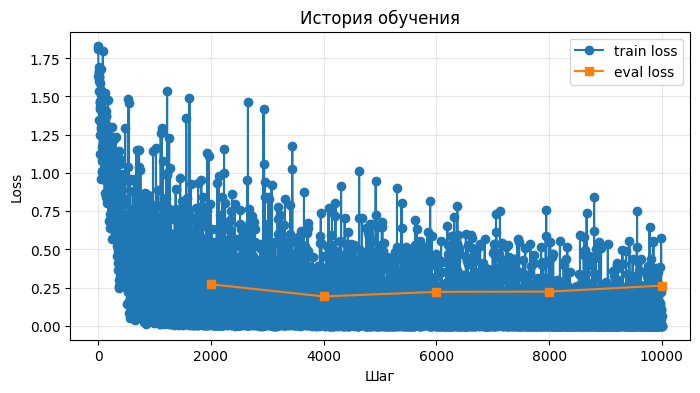

In [ ]:
# История логов Trainer.
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Оценка качества и краткий анализ ошибок

In [ ]:
# В transformers >= 5.x NotebookProgressCallback теряет состояние после обучения,
# что вызывает RuntimeError при вызове evaluate() вне тренировочного цикла.
# Удаляем его перед standalone-оценкой – это стандартный обходной путь.
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

Validation metrics:
eval_loss: 0.2233
eval_accuracy: 0.9395
eval_f1_macro: 0.9172
eval_f1_weighted: 0.9399
eval_runtime: 5.6922
eval_samples_per_second: 351.3550
eval_steps_per_second: 43.9190
epoch: 5.0000

Test metrics:
eval_loss: 0.2524
eval_accuracy: 0.9240
eval_f1_macro: 0.8786
eval_f1_weighted: 0.9243
eval_runtime: 5.6878
eval_samples_per_second: 351.6320
eval_steps_per_second: 43.9540
epoch: 5.0000


Classification report on test:
              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       581
         joy       0.96      0.94      0.95       695
        love       0.81      0.86      0.84       159
       anger       0.94      0.90      0.92       275
        fear       0.85      0.92      0.89       224
    surprise       0.73      0.71      0.72        66

    accuracy                           0.92      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.93      0.92      0.92      2000



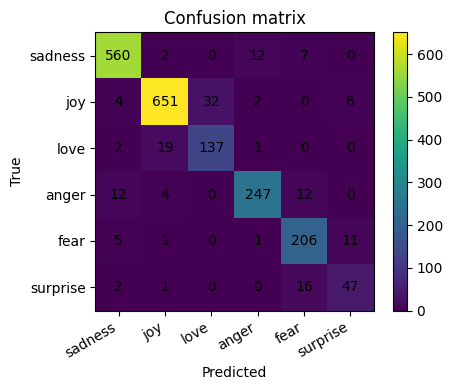

In [ ]:
# Детальные предсказания на тестовой выборке.
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[id2label[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("./artifacts/confusion_matrix.png")
plt.show()

In [ ]:
# Таблица ошибок на тестовой выборке.
test_texts = test_df.reset_index(drop=True)["text"]
error_rows = []

for text, true_id, pred_id, prob_vector in zip(test_texts, test_true, test_preds, torch.softmax(torch.tensor(test_logits), dim=-1).numpy()):
    if true_id != pred_id:
        error_rows.append({
            "text": text,
            "true_label": id2label[int(true_id)],
            "pred_label": id2label[int(pred_id)],
            "pred_confidence": float(prob_vector[pred_id]),
        })

errors_df = pd.DataFrame(error_rows)

if len(errors_df) == 0:
    print("На тестовой выборке ошибок не найдено. Это возможно на маленьком учебном датасете.")
else:
    display(errors_df.sort_values(by="pred_confidence", ascending=False).reset_index(drop=True))

,text,true_label,pred_label,pred_confidence
0,i feel inside cause life is like a game sometimes but then you came around me the walls just disappeared nothing to surround me and keep...,fear,sadness,0.9998
1,i feel cared for and accepted,love,joy,0.9997
2,i feel like i know who most of them are by now and am starting to develop my likes and dislikes though i have not been keen on the snap ...,joy,sadness,0.9997
3,i feel about as helpless and superfluous as i did when jenn had elaine naturally,fear,joy,0.9997
4,i really dont like quinn because i feel like she will just end up hurting barney and i hated the lame ted robin storyline,anger,sadness,0.9997
...,...,...,...,...
147,i just can t feel accepted,love,joy,0.5314
148,i indicated then i was feeling quite overwhelmed with work responsibilities teaching traveling and writing,fear,surprise,0.5278
149,i have this grave feeling it will not be back until tomorrow and strangely enough i have accepted it,joy,love,0.5201
150,i feel so helpless right now,fear,sadness,0.5062


Из примеров ошибок можно сделать вывод, что модель часто не может распознать радость (joy) и печаль (sadness). А также очень часто путает похожие эмоции - радость и любовь.

In [ ]:
sample_df = pd.DataFrame({
    "text": test_texts,
    "true_label": [id2label[i] for i in test_true],
    "pred_label": [id2label[i] for i in test_preds],
    "confidence": np.max(torch.softmax(torch.tensor(test_logits), dim=-1).numpy(), axis=1),
})

sample_df.to_csv("./artifacts/sample_predictions.csv", index=False)